### SECTION A

Plot 1 - Target Distribution: the dataset is imbalanced having more 'answeable' data, meaning the agent can more often than not answer requests

Plot 2 - Live vs. Non-Live: we see 64% are live tasks of the whole, this suggest that our moder will be heavily influenced by static data.

Plot 3 - Task Domain: we can see that our top domain is 'other' which is practically a mixture of catagories which the data-set didnt name. we wont be discarding this catagory but we will not be referencing it, and starting our count at 'trave' which is the second most common catagory

Plot 4 - Task Complexity: we can see that at the low complexity there are more cant answers than in the high and medium, whiv are faily similar
Plot 5 - Aspect Coverage Ratio: on the left side we have the squished box at 0.0, meaning that for the vast majority, the model doesnt refuse, we also have a few outliers which means this is not 100% proof. on the other side of 'can answer' we see the box is covering everything from 0.0-1.0, this tells us that the aspect_covrage_ratio is not required for a task to be answerable

C:\Users\User\AppData\Local\Temp\ipykernel_5620\3618090954.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='can_answer', palette='viridis')


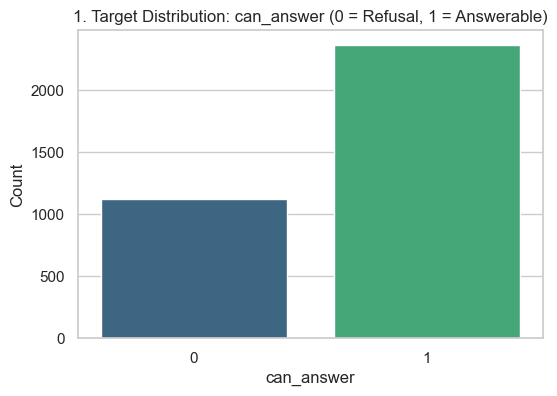

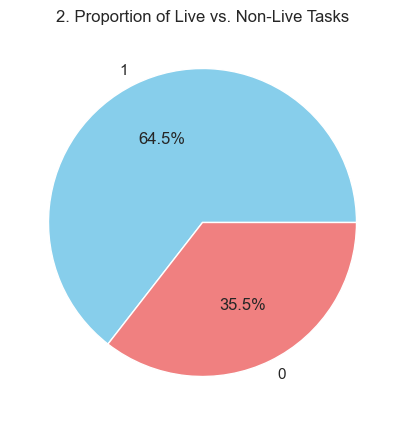

C:\Users\User\AppData\Local\Temp\ipykernel_5620\3618090954.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='task_domain', order=df['task_domain'].value_counts().index, palette='magma')


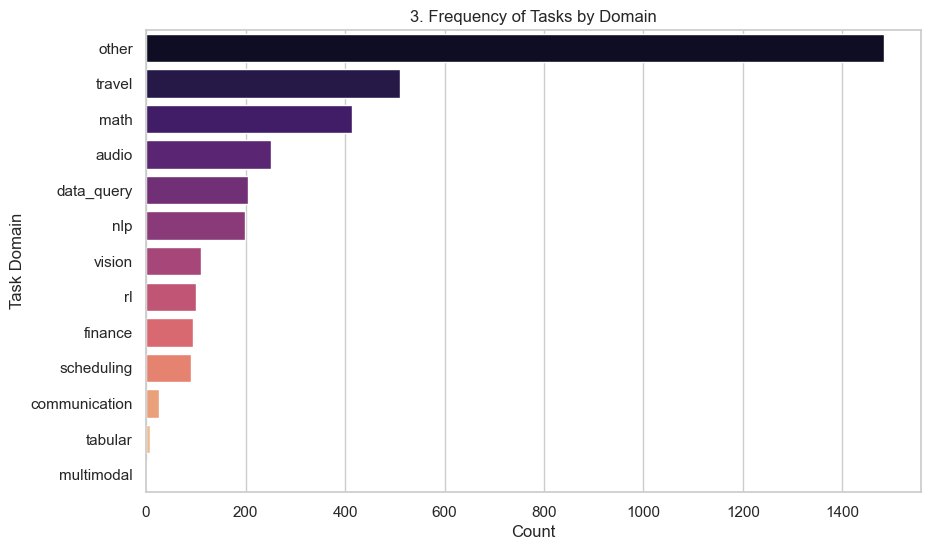

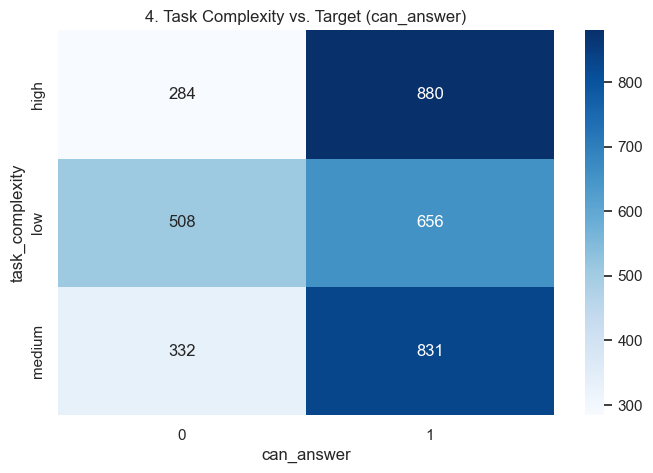

C:\Users\User\AppData\Local\Temp\ipykernel_5620\3618090954.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='can_answer', y='aspect_coverage_ratio', palette='Set2')


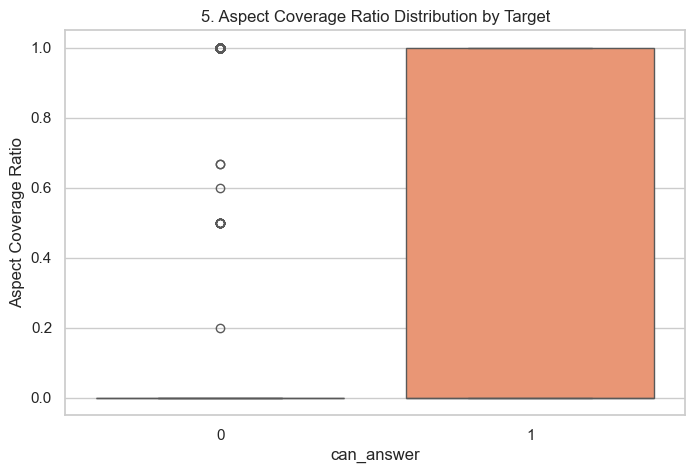

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the uploaded dataset
df = pd.read_csv('agent_tool_tasks.csv')

# Set visual style for consistency
sns.set_theme(style="whitegrid")

# --- Plot 1: Target Distribution (can_answer) ---
# Plot Type: Bar Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='can_answer', palette='viridis')
plt.title('1. Target Distribution: can_answer (0 = Refusal, 1 = Answerable)')
plt.xlabel('can_answer')
plt.ylabel('Count')
plt.show()

# --- Plot 2: Live vs. Non-Live Tasks (is_live_benchmark) ---
# Plot Type: Pie Chart
plt.figure(figsize=(5, 5))
live_counts = df['is_live_benchmark'].value_counts()
plt.pie(live_counts, labels=live_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('2. Proportion of Live vs. Non-Live Tasks')
plt.show()

# --- Plot 3: Task Domain ---
# Plot Type: Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='task_domain', order=df['task_domain'].value_counts().index, palette='magma')
plt.title('3. Frequency of Tasks by Domain')
plt.xlabel('Count')
plt.ylabel('Task Domain')
plt.show()

# --- Plot 4: Task Complexity ---
# Plot Type: Heatmap (Crosstab Table)
plt.figure(figsize=(8, 5))
complexity_crosstab = pd.crosstab(df['task_complexity'], df['can_answer'])
sns.heatmap(complexity_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('4. Task Complexity vs. Target (can_answer)')
plt.show()

# --- Plot 5: Query/Tool Matching (aspect_coverage_ratio) ---
# Plot Type: Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='can_answer', y='aspect_coverage_ratio', palette='Set2')
plt.title('5. Aspect Coverage Ratio Distribution by Target')
plt.xlabel('can_answer')
plt.ylabel('Aspect Coverage Ratio')
plt.show()

### SECTION B

#### part 1

In [ ]:
import numpy as np
import pandas as pd

# 1. required_params_ratio
df['required_params_ratio'] = np.where(
    df['total_params'] == 0, 
    0, 
    df['total_required_params'] / df['total_params']
)

# 2. avg_params_per_tool
df['avg_params_per_tool'] = np.where(
    df['num_available_tools'] == 0, 
    0, 
    df['total_params'] / df['num_available_tools']
)

# 3. query_avg_word_length
def calc_avg_word_length(text):
    if pd.isna(text): 
        return 0
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df['query_avg_word_length'] = df['query'].apply(calc_avg_word_length)

# 4. query_mentions_number
df['query_mentions_number'] = df['query'].astype(str).str.contains(r'\d', regex=True).astype(int)

# 5. tool_name_diversity
def count_unique_prefixes(tools_str):
    if pd.isna(tools_str) or str(tools_str).strip() == '':
        return 0
    
    tools = str(tools_str).split('|')
    prefixes = set()
    
    for tool in tools:
        tool = tool.strip()
        if tool:  # מוודא שהשם לא ריק
            prefix = tool.split('.')[0]
            prefixes.add(prefix)
            
    return len(prefixes)

df['tool_name_diversity'] = df['tool_names'].apply(count_unique_prefixes)

#### part 2

#### Feature1 : query_word_count
calculates the total number of words in the user's query.

Very short queries often lack the necessary context or specific parameters required to successfully trigger a tool. Therefore, shorter queries are more likely to be refusal cases, making this a useful distinguishing feature.

##### Feature2: optional_params_count
It measures the number of optional parameters a tool has by subtracting the strictly required parameters from the total parameters.

It indicates tool flexibility. Tools with a higher number of optional parameters can handle a wider variety of queries and incomplete inputs, potentially increasing the chance of a successful tool call rather than a flat refusal.

##### Feature 3: aspect_match_ratio
calculates the ratio of overlapping aspects out of all the relevant aspects evaluated between the query and the tool.

It provides a normalized numerical metric of how well the query's intent aligns with the available tools. A higher ratio predicts an answerable case.

##### Feature 4: param_to_word_ratio
calculates the ratio between the total parameters required by the tools and the total number of words provided in the user's query.

It helps identify information gaps. If a tool requires a large number of parameters but the user provided a very short query, the agent likely does not have enough information to execute the tool, indicating a probable refusal case.

##### Feature 5: max_tool_name_similarity
calculates a fuzzy string matching score (between 0.0 and 1.0) to determine how closely the available tool names resemble the words used in the user's query.

Users often refer to tools explicitly but make formatting errors. A high similarity score strongly indicates that the user is intentionally asking for a specific tool, guiding the model to predict an answerable task with higher confidence, while remaining flexible to human typing patterns.

In [4]:
# Feature 1: Query Word Count
df['query_word_count'] = df['query'].astype(str).apply(lambda x: len(x.split()))

# Feature 2: Number of Optional Parameters
df['optional_params_count'] = df['total_params'] - df['total_required_params']

# Feature 3: Aspect Match Ratio (+1 in denominator to prevent division by zero)
df['aspect_match_ratio'] = df['aspect_overlap_count'] / (df['aspect_overlap_count'] + df['aspect_mismatch_count'] + 1)

# Feature 4: Parameter to Word Ratio (Requires feature 1 to be executed first)
df['param_to_word_ratio'] = df['total_params'] / (df['query_word_count'] + 1)


# Feature 5 (Upgraded): Max Tool Name Similarity Score
import difflib
def calc_max_tool_similarity(row):
    if pd.isna(row['tool_names']) or pd.isna(row['query']):
        return 0.0
    
    query = str(row['query']).lower()
    tools = str(row['tool_names']).lower().split('|')
    
    query_words = query.replace('_', ' ').replace('-', ' ').split()
    max_score = 0.0
    
    for tool in tools:
        tool = tool.strip()
        if not tool:
            continue
            
        tool_spaced = tool.replace('_', ' ').replace('-', ' ')
        tool_connected = tool.replace('_', '').replace('-', '')
        
        for i in range(len(query_words)):
            score1 = difflib.SequenceMatcher(None, tool_spaced, query_words[i]).ratio()
            max_score = max(max_score, score1)
            
            if i < len(query_words) - 1:
                pair_spaced = query_words[i] + ' ' + query_words[i+1]
                score2 = difflib.SequenceMatcher(None, tool_spaced, pair_spaced).ratio()
                max_score = max(max_score, score2)
                
                pair_connected = query_words[i] + query_words[i+1]
                score3 = difflib.SequenceMatcher(None, tool_connected, pair_connected).ratio()
                max_score = max(max_score, score3)
                
    return max_score

df['max_tool_name_similarity'] = df.apply(calc_max_tool_similarity, axis=1)

#### part 3

In [ ]:
b3 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

# --- 1. הסרת עמודות שאסור להשתמש בהן כקלט ישיר למודל ---
forbidden_cols = ['task_uid', 'query', 'tool_names', 'can_answer']
X = df.drop(columns=forbidden_cols)
y = df['can_answer']

# --- 2. כלל ברזל: פיצול הנתונים *לפני* התאמת אימפיוטרים/מקודדים ---
# א. פיצול ראשון ל-80% אימון ו-20% זמני (שייחתך לחצי בהמשך)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ב. פיצול שני ל-10% ולידציה ו-10% טסט
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# --- 3. Feature Exclusion (בחירת/השמטת מאפיינים) ---
# נשמיט את עמודות האספקטים שמכילות '|' ואת 'total_required_params' שיש לו קורלציה גבוהה
cols_to_exclude = ['query_aspects', 'tool_aspects', 'total_required_params']
X_train = X_train.drop(columns=cols_to_exclude, errors='ignore')
X_val = X_val.drop(columns=cols_to_exclude, errors='ignore')
X_test = X_test.drop(columns=cols_to_exclude, errors='ignore')

# --- 4. טיפול בערכים חסרים (Missing Values) ---
# טיפול בעמודה avg_param_description_length וכל עמודה מספרית אחרת
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[numeric_cols]) # FIT מתבצע *רק* על סט האימון!

X_train[numeric_cols] = imputer.transform(X_train[numeric_cols])
X_val[numeric_cols] = imputer.transform(X_val[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

# --- 5. התמרות (Transformations) ---
# א. קידוד One-Hot לעמודות הקטגוריאליות
categorical_cols = ['task_domain', 'task_complexity']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols]) # FIT רק על האימון

def encode_df(X_data, enc, cat_cols):
    encoded_arr = enc.transform(X_data[cat_cols])
    encoded_df = pd.DataFrame(encoded_arr, columns=enc.get_feature_names_out(cat_cols), index=X_data.index)
    return pd.concat([X_data.drop(columns=cat_cols), encoded_df], axis=1)

X_train = encode_df(X_train, encoder, categorical_cols)
X_val = encode_df(X_val, encoder, categorical_cols)
X_test = encode_df(X_test, encoder, categorical_cols)

# ב. Scaling (תקנון) למאפיינים המספריים 
scaler = StandardScaler()
# מעדכנים את רשימת העמודות המספריות לאחר ההשמטות והקידוד
current_numeric = [c for c in X_train.columns if X_train[c].dtype in ['float64', 'int64']]

scaler.fit(X_train[current_numeric]) # FIT רק על האימון

X_train[current_numeric] = scaler.transform(X_train[current_numeric])
X_val[current_numeric] = scaler.transform(X_val[current_numeric])
X_test[current_numeric] = scaler.transform(X_test[current_numeric])


### B.3 Cleaning and Transformation Steps Explained

1. **Data Splitting:** Data was strictly split into Train (80%), Validation (10%), and Test (10%) sets *before* fitting any imputers, scalers, or encoders to prevent data leakage.
2. **Missing Values:** Missing values in `avg_param_description_length` and other numeric columns were handled using a median `SimpleImputer`, fitted exclusively on the training set.
3. **Transformations:** Applied `StandardScaler` to numeric features and `OneHotEncoder` to the categorical columns (`task_domain`, `task_complexity`).
4. **Feature Exclusion & Pipe-Separated Columns:** * Excluded the pipe-separated columns (`query_aspects`, `tool_aspects`). Since we already have numerical features representing aspect matching (e.g., `aspect_coverage_ratio`), one-hot encoding these raw strings would result in massive, sparse dimensionality and potential overfitting.
   * Excluded `total_required_params` due to its high collinearity with `total_params` as a valid feature selection step to reduce redundancy.

### SECTION C

### SECTION D